# Analysis: Model Performance

Here we focus on capturing differences in model performance.

**Performance score** is calculated by:
- train models with inner and outer folds (10 outer folds, with 9 inner folds each)
- measure the cross-entropy, or Negative Log Likelihood (NLL), of next-action predictions in train, val (inner) and eval (outer) datasets.
- for each subject, each outer fold, select the inner fold with lowest NLL across train and inner validation datasets.
- for each subject, we take the mean across outer folds.
- Statistics are done at subject-level: for each subject, we therefore take the mean across outer folds for a subject-level score.


**Architectures** we have trained models which differ in:
- gating mechanisms ['GRU','lightGRU','monoGRU','vanilla']
- dimensionality [1, 2 or 3 hidden units]
- activation function ['relu', 'tanh']
- input encodings ['unipolar','onehot','encoder']
- decoder bias [with or without]

In [4]:
## setup ##
import os
os.chdir('/ceph/behrens/wsilver/reversal/code/')

from NM_TinyRNN.code.measures import analysis
from NM_TinyRNN.code.measures import mechanistic_variability as mech_var
#from NM_TinyRNN.code.measures import reversal_metrics as revme
from NM_TinyRNN.code.measures import plotting_stats
from NM_TinyRNN.code.measures import performance as perf

from NM_TinyRNN.code.models import submit_jobs # this is the code used to train models!

import numpy as np
import pandas as pd
import torch #for testing a few things
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from importlib import reload

CODE_DIR = Path('.') ## OBS THIS MAY NEED TO BE ADJUSTED!
SAVE_PATH = CODE_DIR/'NM_TinyRNN/data/rnns'
DATA_PATH = Path('./NM_TinyRNN/data/AB_behaviour/')

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
#construct analysis_df and have a look at a subset of data!
info_df = submit_jobs.get_DA_info_df() #code used to submit jobs
all_models_df = analysis.get_analysis_df(info_df, mode='all') #code to aggregate all paths and some data
performance_df = perf.get_performance_df(all_models_df) #code to recompute evaluations and aggregate
best_model_df = perf.select_best_outer(performance_df) #
subject_level_df = perf.compute_outer_mean(best_model_df)

print("Available model types (model_type2):")
print(all_models_df.model_type2.unique())

print("\nAvailable columns:")
print([col for col in all_models_df.columns if 'CE' in col or 'type' in col])


Loaded analysis paths from cache: NM_TinyRNN/data/analysis/analysis_df_final.htsv
Loaded performance dataframe from cache: NM_TinyRNN/data/analysis/performance_df_final.htsv
Available model types (model_type2):
['GRU+BC' 'GRU+BC-DB' 'GRU' 'monoGRU+BC' 'monoGRU+BC-DB']

Available columns:
['model_type', 'model_type2']


In [22]:
all_models_df.query('subject_id=="WS20"')

,Index,subject_id,outer_loop_n,model_type,hidden_size,nonlinearity,constraint,decoder_bias,input_encoding,input_forced_choice,...,save_path,data_path,completed,model_type2,inner_loop_idx,info_path,model_state_path,model_pickle_path,training_losses_path,trials_data_path
0,0,WS20,1,GRU,1,relu,energy,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/energy,NM_TinyRNN/data/AB_behaviour/WS20,1,GRU+BC,0,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...
1,0,WS20,1,GRU,1,relu,energy,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/energy,NM_TinyRNN/data/AB_behaviour/WS20,1,GRU+BC,1,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...
2,0,WS20,1,GRU,1,relu,energy,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/energy,NM_TinyRNN/data/AB_behaviour/WS20,1,GRU+BC,2,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...
3,0,WS20,1,GRU,1,relu,energy,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/energy,NM_TinyRNN/data/AB_behaviour/WS20,1,GRU+BC,3,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...
4,0,WS20,1,GRU,1,relu,energy,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/energy,NM_TinyRNN/data/AB_behaviour/WS20,1,GRU+BC,4,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/GRU/ener...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
823,99,WS20,10,monoGRU,2,relu,energy,False,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/AB_behaviour/WS20,1,monoGRU+BC-DB,4,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...
824,99,WS20,10,monoGRU,2,relu,energy,False,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/AB_behaviour/WS20,1,monoGRU+BC-DB,5,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...
825,99,WS20,10,monoGRU,2,relu,energy,False,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/AB_behaviour/WS20,1,monoGRU+BC-DB,6,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...
826,99,WS20,10,monoGRU,2,relu,energy,False,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/AB_behaviour/WS20,1,monoGRU+BC-DB,7,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...,NM_TinyRNN/data/rnns/nested_DA_8/WS20/monoGRU/...


# Main

## Ji-an style plot: comparing 1 and 2 unit models across architectures.


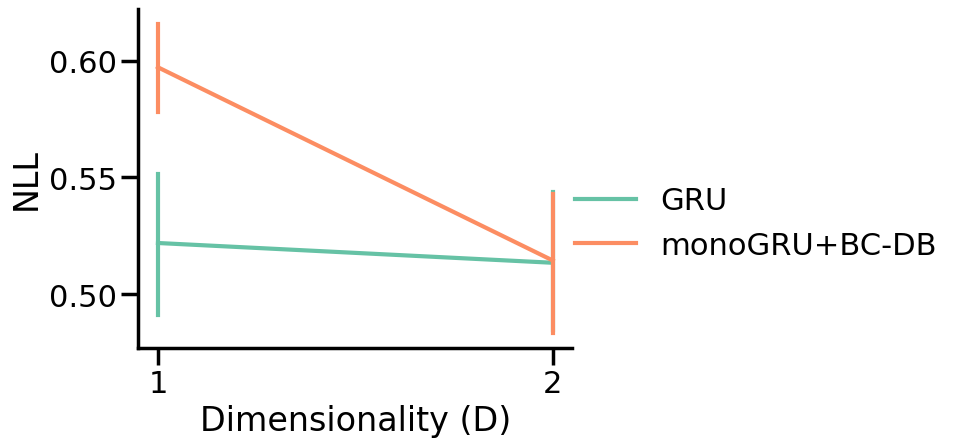

In [6]:


sns.set_context('poster')
model_list = ["GRU", "monoGRU+BC-DB"]
unipolar_models = subject_level_df.query('input_encoding=="unipolar"')
unipolar_models = unipolar_models[unipolar_models.model_type2.isin(model_list)]
#unipolar_models = unipolar_models.query('n_outer_folds==10')

g = sns.relplot(unipolar_models, x='hidden_size',y='eval_CE_computed', kind = 'line', 
                hue= 'model_type2', palette = "Set2",
                err_style = 'bars',
                col_order = ['tanh','relu'],
                hue_order = model_list,
                aspect = 1.4)
g.legend.set(title = '')
g.set(ylabel = 'NLL', xlabel = 'Dimensionality (D)', xticks = [1,2])

## Unipolar models: are 1-unit models better than 2-unit models?

We focus on unipolar encodings, as these were adopted by Ji-an et al., and seem the 'most' biological when considering the temporal separation of different events.



PAIRED COMPARISON DIAGNOSTIC RUN REPORT
        group            test_used                 reason  outliers_present  p_corrected
          GRU Wilcoxon Signed-Rank      Outliers detected              True     0.009766
monoGRU+BC-DB Wilcoxon Signed-Rank Non-normal differences             False     0.001953



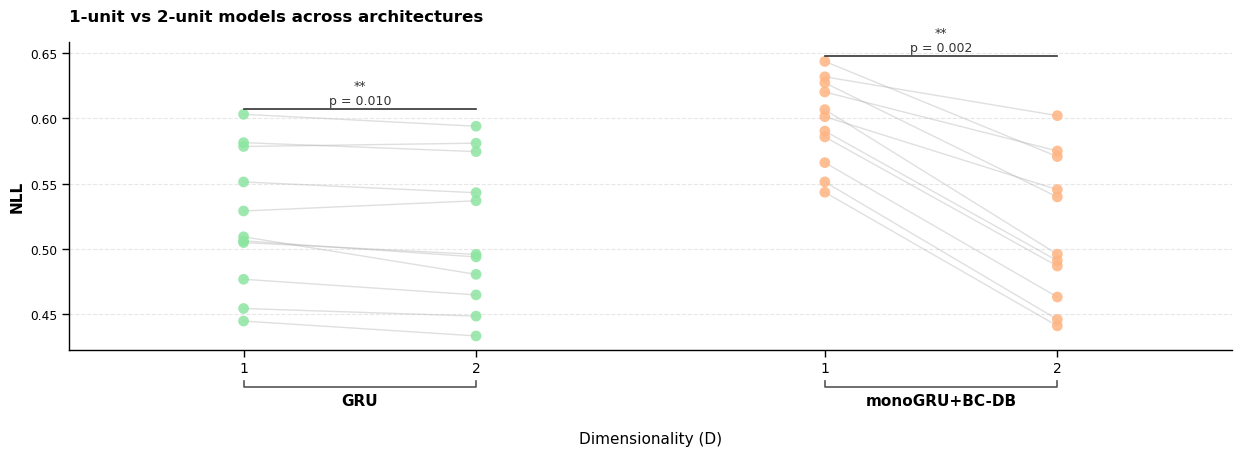

In [7]:
## Are 1D models better than 2D models?
reload(analysis)
reload(plotting_stats)
#we compare vanilla and GRU with different input encodings
sns.set_context('paper')
model_list = ['GRU','monoGRU+BC-DB']
fig, ax = plt.subplots(figsize = (15,4))
select_models = subject_level_df[subject_level_df.model_type2.isin(model_list)]
select_models = select_models.query('input_encoding == "unipolar"')

palette = sns.color_palette('pastel')[0:3]
palette = (palette[2], palette[1],palette[0])
axis, ttest = plotting_stats.plot_paired_comparison(select_models,
                                                y='eval_CE_computed',
                                                x='hidden_size',
                                                within_variable='model_type2', 
                                                paired_across='subject_id',
                                                hue_order = model_list, 
                                                colors = palette, 
                                                ax = ax,
                                                title = "1-unit vs 2-unit models across architectures")

axis.set(ylabel = 'NLL', xlabel = 'Dimensionality (D)')
plt.show()
    

## Unipolar 2 unit models: difference across architectures

We want to compare model performance of 2-unit models across the different architectures. Here we preform an ANOVA.




N subjects with complete data: 11

Repeated measures ANOVA:
     Source  ddof1  ddof2        F    p_unc      ng2  eps
model_type2      1     10 0.413631 0.534601 0.000086  1.0

Post-hoc paired t-tests (fdr_bh corrected):
  monoGRU+BC-DB vs GRU: t=0.64, mean_diff=0.0010, p_raw=0.5346, p_corr=0.5346 n.s.


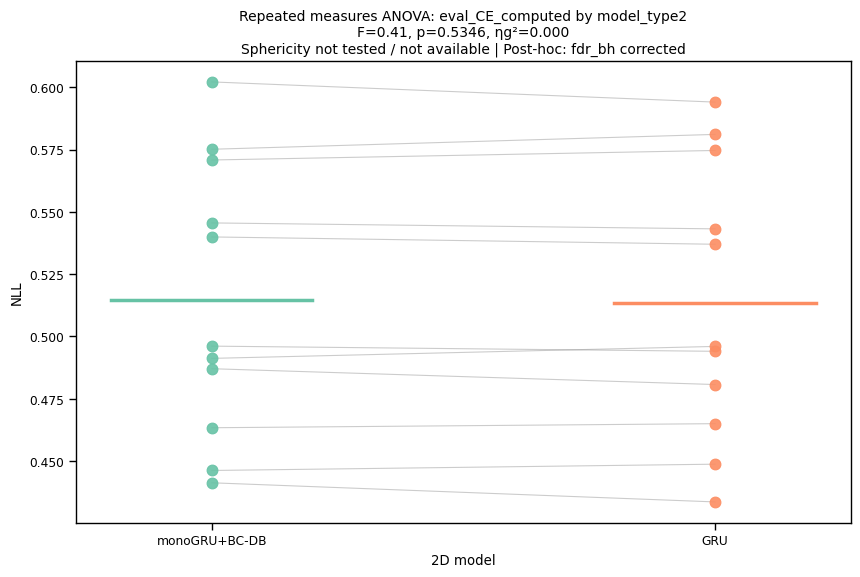

In [8]:
## Are 1D models better than 2D models?
reload(analysis)
reload(plotting_stats)
#we compare vanilla and GRU with different input encodings
sns.set_context('paper')
model_list = ['GRU','monoGRU+BC-DB']
select_models = subject_level_df[subject_level_df.model_type2.isin(model_list)]
select_models = select_models.query('input_encoding == "unipolar"')
select_models = select_models.query('hidden_size==2')

palette = sns.color_palette('pastel')[0:3]
palette = (palette[2], palette[1],palette[0])

fig, ax = plt.subplots(figsize=(10, 6))
anova_result, pair_results, ax = plotting_stats.plot_repeated_measures_anova(select_models,
                                            y='eval_CE_computed',
                                            x='model_type2',
                                            paired_across='subject_id',
                                            mean_across=None,ax=ax)
ax.set(xlabel='2D model', ylabel='NLL')

axis.set(ylabel = 'NLL', xlabel = 'Dimensionality (D)')
plt.show()
    

In [9]:
all_models_df.model_type2.unique()

array(['GRU+BC', 'GRU+BC-DB', 'GRU', 'monoGRU+BC', 'monoGRU+BC-DB'],
      dtype=object)

   model_a       model_b  n_subjects  statistic  p_value  median_difference  p_adjusted
 GRU+BC-DB monoGRU+BC-DB          11        7.0 0.018555          -0.002451    0.185547
    GRU+BC monoGRU+BC-DB          11       10.0 0.041992          -0.002496    0.209961
    GRU+BC    monoGRU+BC          11       15.0 0.123047          -0.000651    0.294922
       GRU        GRU+BC          11       16.0 0.147461           0.000852    0.294922
       GRU     GRU+BC-DB          11       14.0 0.101562           0.001382    0.294922
 GRU+BC-DB    monoGRU+BC          11       18.0 0.206055          -0.002138    0.343424
       GRU monoGRU+BC-DB          11       26.0 0.577148          -0.002080    0.824498
    GRU+BC     GRU+BC-DB          11       29.0 0.764648          -0.000045    0.955811
       GRU    monoGRU+BC          11       33.0 1.000000           0.001477    1.000000
monoGRU+BC monoGRU+BC-DB          11       32.0 0.965820           0.000574    1.000000


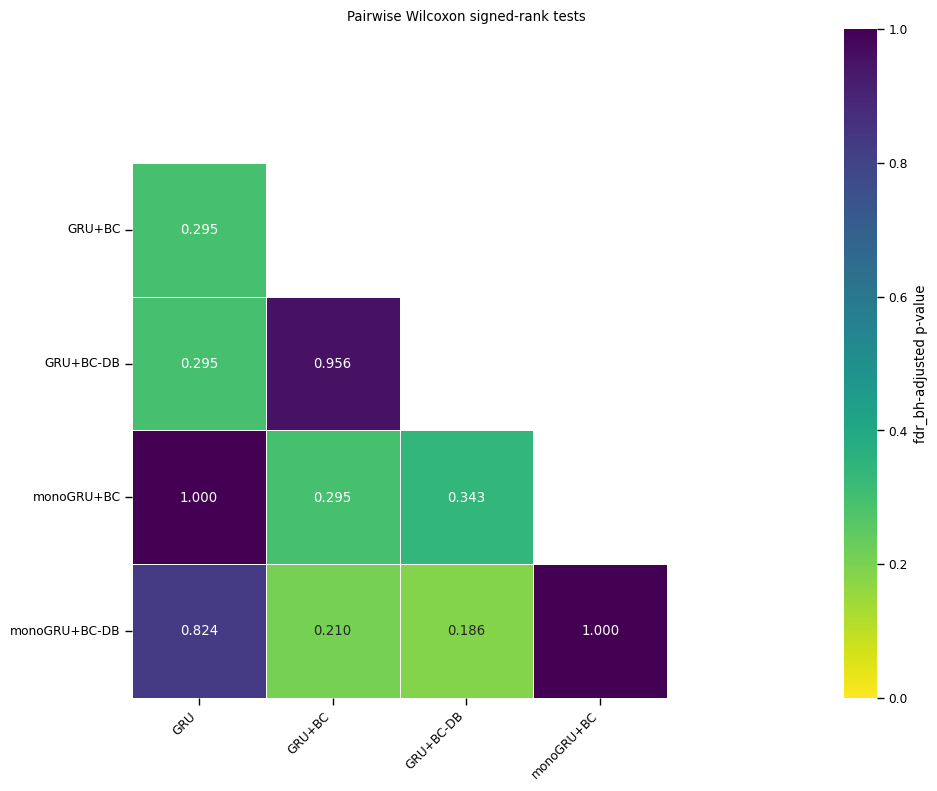

In [10]:
# Pairwise subject-level comparison of all selected models
reload(plotting_stats)
sns.set_context('paper')
model_list = [
    'GRU', 'GRU+BC', 'GRU+BC-DB',
    'monoGRU+BC', 'monoGRU+BC-DB'
]

models = subject_level_df.query(
    'hidden_size == 2 and input_encoding == "unipolar"'
).loc[lambda dataframe: dataframe.model_type2.isin(model_list)]

fig, ax = plt.subplots(figsize=(10, 8))
ax, pairwise_results = plotting_stats.plot_pairwise_wilcoxon(
    models,
    value_col='eval_CE_computed',
    model_order=model_list,
    ax=ax,
)
print(pairwise_results.sort_values('p_adjusted').to_string(index=False))
plt.tight_layout()
plt.show()


# Supplementary

Here we include further explorations which supplement the primary narrative of the paper

## per-subject inner x outer loop losses

We are interested in knowing whether there's a trend towards some folds having worse fits.

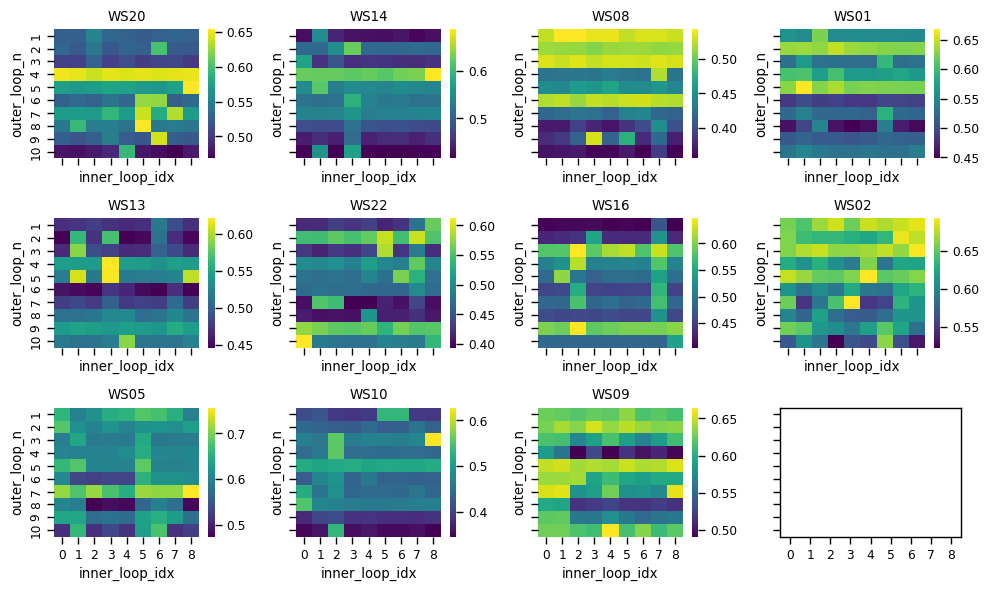

In [11]:
# for example, let's select a particular model
sns.set_context('paper')
model_id = '2_unit_monoGRU_relu_unipolar_forced_ndb' #minimal variation monoGRU
model_df = performance_df.query(f'model_id=="{model_id}"')
fig, ax = plt.subplots(3,4, figsize = (10,6), sharex = True, sharey=True)
flat_ax = ax.flatten()
for i, each_subject in enumerate(model_df.subject_id.unique()):
    subject_df = model_df.query(f'subject_id=="{each_subject}"')
    pivot_df = subject_df.pivot(index="outer_loop_n",columns = "inner_loop_idx",values="eval_CE_computed")
    sns.heatmap(pivot_df, ax=flat_ax[i], cmap='viridis')
    flat_ax[i].set_title(f'{each_subject}')
    
fig.tight_layout()

## Exploring the role of input encodings

